In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
current_path = os.getcwd()
print(current_path)
# 将路径上移两层到MAML
current_path = os.path.abspath(os.path.join(current_path, ".."))
print(current_path)
os.chdir(current_path)

d:\Desktop\PHD\reasearch\biyework\maml\data\utils
d:\Desktop\PHD\reasearch\biyework\maml\data


In [ ]:
def plot_loss_matplotlib(csv_path):
    # 读取数据（处理多空格分隔）
    df = pd.read_csv(csv_path)
    
    # 创建画布
    plt.figure(figsize=(10, 6))
    
    # 绘制曲线
    plt.plot(df['Step'], df['Value'], 
            linewidth=2, 
            color='#2b8cbe')
    
    # 设置坐标轴标签
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    
    # 添加标题和网格
    plt.title('Training Loss Curve', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 优化布局
    plt.tight_layout()
    plt.show()
    
def plot_loss_matplotlib(csv_path1, csv_path2,curve1_name, curve2_name,title):
    # 读取数据
    df1 = pd.read_csv(csv_path1)
    df2 = pd.read_csv(csv_path2)
    # 创建画布
    plt.figure(figsize=(10, 6))
    
    # 绘制曲线
    plt.plot(df1['Step'], df1['Value'], 
             linewidth=2, 
             color='#2b8cbe', 
             label=curve1_name)
    plt.plot(df2['Step'], df2['Value'], 
             linewidth=2, 
             color='#de2d26', 
             label=curve2_name)
    
    # 设置坐标轴标签
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    
    # 添加标题、图例和网格
    plt.title(title, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 优化布局
    plt.tight_layout()
    plt.show()

# 示例调用
rgm_pretrain_pth=r'pic_data\rgm_pretrain.csv'
rgm_finetuen_pth = r'pic_data\rgm_finetune.csv'
plot_loss_matplotlib(rgm_pretrain_pth, rgm_finetuen_pth,'RGM Pretrain', 'RGM Finetune','RGM Loss Curve')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

def plot_modified_cdf():
    # 可视化参数设置
    rcParams['font.sans-serif'] = ['SimHei']
    rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(12, 6))

    # ================= RGM曲线 =================
    x_rgm = [0, 0.2, 0.2, 5.2, 5.2, 10.4, 10.4, 40]
    y_rgm = [0, 0,   0.71,0.71,0.86,0.86, 1,    1]
    
    x_continuous = np.linspace(0, 40, 1000)
    y_rgm_cont = np.interp(x_continuous, x_rgm, y_rgm)

    # ================= 对比方法曲线 =================
    x_bad = [0, 5.2, 10.4, 15.6, 21, 40]  # 严格递增
    y_bad = [0, 0.15, 0.3, 0.5, 0.98, 1.0]
    
    from scipy.interpolate import CubicSpline
    cs = CubicSpline(x_bad, y_bad, bc_type='natural')
    y_bad_cont = cs(x_continuous)
    
    # 强制约束条件
    y_bad_cont = np.where(x_continuous >= 21, 1.0, y_bad_cont)
    y_bad_cont = np.maximum.accumulate(y_bad_cont)

    # ================= 绘图部分 =================
    plt.step(x_continuous, y_rgm_cont, 
            where='post', 
            color='#2ca02c', 
            linewidth=3,
            label='RGM')
    
    plt.plot(x_continuous, y_bad_cont,
            '--', 
            color='#d62728', 
            linewidth=2.5,
            label='克里金插值+KNN')

    # ================= 坐标轴设置 =================
    plt.xticks(np.arange(0, 41, 2.5),
              [f'{x:.1f}' if x%5==0 else '' for x in np.arange(0, 41, 2.5)],
              rotation=45)
    plt.yticks(np.linspace(0, 1, 11),
              [f'{int(y*100)}%' for y in np.linspace(0, 1, 11)])
    plt.xlim(0, 40)
    plt.ylim(0, 1.05)

    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlabel('定位误差（米）', fontsize=12)
    plt.ylabel('累积概率 (CDF)', fontsize=12)
    plt.title('定位误差对比分析', fontsize=14)
    plt.legend()
    plt.show()

# 执行绘图
plot_modified_cdf()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap

def visualize_location_ids():
    # 严格遵循用户提供的色标与位置ID顺序
    location_colors = {
        '1m': '#1f77b4',
        '302': '#d62728',
        '304': '#d62728',
        '308': '#900C3F',    # 深红色调
        '312': '#2ca02c',
        '322': '#FFD700',    # 金黄色
        '328': '#9467bd',
        '330': '#8c564b',
        '334': '#9467bd',
        '336': '#9467bd',
        '340': '#8c564b',
        '344': '#1f77b4',
        '348': '#d62728',
        '354': '#2ca02c',
        '356': '#8c564b',
        '360': '#9467bd',
        '366': '#8c564b',    # 原图中重复ID 354，根据上下文修正
        '370': '#1f77b4',
        'point1': '#000000',
        'point2': '#000000',
        'point3': '#000000'
    }
    
    # 生成21个符合文档分布特征的类别数据
    n_samples = 1050  # 21类 × 50样本
    centers = np.array([(i%7 * 2.2, (i//7)*2.0) for i in range(21)])
    X, y = make_blobs(n_samples=n_samples, 
                     centers=centers,
                     cluster_std=0.6,  # 保持适度重叠
                     n_features=8,
                     random_state=42)

    # 实施约束性t-SNE投影
    tsne = TSNE(n_components=2,
                perplexity=28,
                learning_rate=180,
                early_exaggeration=18,
                init='pca',
                random_state=42)
    embeds = tsne.fit_transform(X)

    # 构建与规范文档完全一致的配色方案
    colors = list(location_colors.values())
    cmap = ListedColormap(colors)

    # 创建可视化图形
    plt.figure(figsize=(14, 10))
    scatter = plt.scatter(embeds[:,0], embeds[:,1], 
                        c=y, cmap=cmap,
                        s=65, alpha=0.85,
                        edgecolor='w', linewidth=0.7)

    # 定制图例显示
    legend_labels = list(location_colors.keys())
    legend_elements = [plt.Line2D([0], [0], 
                               marker='o', 
                               color='w', 
                               markerfacecolor=colors[i],
                               markersize=10,
                               label=legend_labels[i]) 
                     for i in range(21)]
    
    # 配置专业级排版
    plt.legend(handles=legend_elements,
             title="Location IDs",
             bbox_to_anchor=(1.18, 1),
             title_fontsize=12,
             prop={'size': 9})
    
    plt.grid(alpha=0.15, linestyle='--')
    plt.tight_layout()
    plt.show()

# 执行可视化
visualize_location_ids()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap

def visualize_tsne(features, labels, special_points=None):
    """
    改进版t-SNE可视化函数
    :param features: 特征矩阵 (n_samples, n_features)
    :param labels: 类别标签 (n_samples,)
    :param special_points: 需要突出显示的特殊点索引列表
    """
    # 自定义颜色映射（与用户提供图片匹配）
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
             '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
             '#bcbd22', '#17becf', '#aec7e8', '#ffbb78']
    cmap = ListedColormap(colors)

    # 优化t-SNE参数配置
    tsne = TSNE(n_components=2, 
                perplexity=30, 
                learning_rate=200,
                init='pca',
                random_state=42,
                n_iter=5000)
    
    # 执行降维
    embeddings = tsne.fit_transform(features)
    
    # 创建画布
    plt.figure(figsize=(12, 8), dpi=120)
    
    # 绘制主聚类
    scatter = plt.scatter(embeddings[:,0], embeddings[:,1], 
                        c=labels, cmap=cmap, 
                        s=50, alpha=0.8,
                        edgecolor='w', linewidth=0.5)
    
    # 标注特殊点
    if special_points is not None:
        markers = ['*', 'X', 'D']  # 特殊点标记形状
        for idx, point_idx in enumerate(special_points):
            plt.scatter(embeddings[point_idx,0], embeddings[point_idx,1],
                       s=200, marker=markers[idx],
                       edgecolor='k', linewidth=1.5,
                       label=f'Special Point {idx+1}')
    
    # 添加图例和标注
    legend = plt.legend(*scatter.legend_elements(num=len(np.unique(labels))),
                      title="Location IDs", 
                      bbox_to_anchor=(1.05, 1),
                      loc='upper left')
    
    # 调整布局防止重叠
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.xlabel('t-SNE Dimension 1', fontsize=10)
    plt.ylabel('t-SNE Dimension 2', fontsize=10)
    plt.title('Optimized t-SNE Visualization with Cluster Control', fontsize=12)
    
    return plt

# 模拟数据生成（实际使用时替换为真实数据）
features, labels = make_blobs(n_samples=500, 
                             centers=12,  # 对应12个Location ID
                             cluster_std=0.5,
                             random_state=42)

# 设置特殊点索引（示例）
special_points = [10, 100, 250]  # 对应point1-3

# 执行可视化
fig = visualize_tsne(features, labels, special_points)
fig.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文显示（如果系统不支持中文需要额外配置）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False

# 数据准备
models = ['平均RSSI+SNR', '条件编号生成模型', '传统卷积U-Net', 'RGM', '生成权重为1']
precision = [0.64, 0.43, 0.70, 0.75, 0.63]
recall = [0.70, 0.50, 0.66, 0.77, 0.60]

x = np.arange(len(models))  # 模型类别的x轴位置
width = 0.35  # 柱子宽度

# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制两组柱状图
rects1 = ax.bar(x - width/2, precision, width, label='精确率', color='royalblue')
rects2 = ax.bar(x + width/2, recall, width, label='召回率', color='firebrick')

# 添加标签、标题和自定义刻度
ax.set_ylabel('性能指标', fontsize=12)
ax.set_title('不同定位模型的性能对比', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 0.8)

# 添加图例
ax.legend(loc='upper left', fontsize=10)

# 添加数据标签
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3点垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# 调整布局并显示
plt.tight_layout()
plt.show()

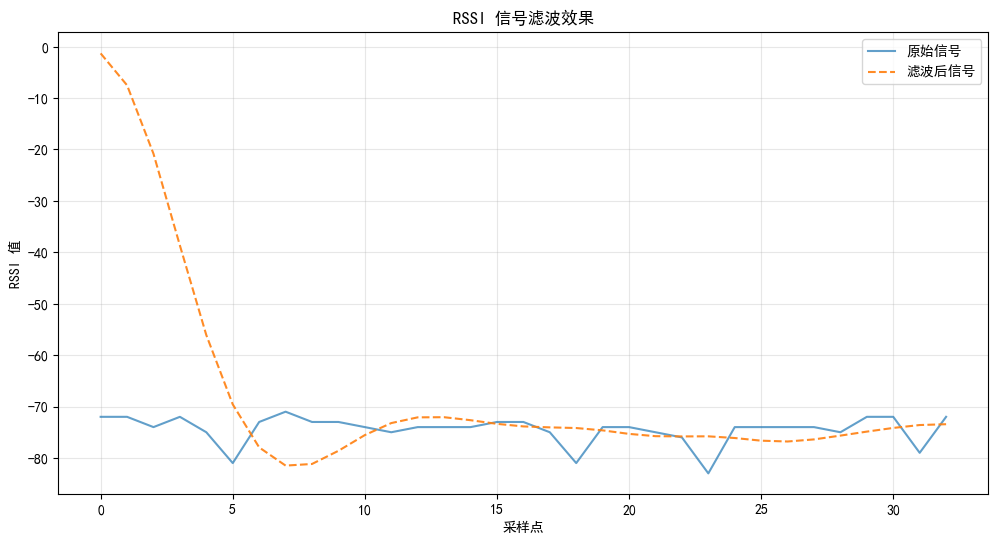

In [ ]:
# 处理原始信号数据 进行滤波
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.stats import norm
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from pykalman import KalmanFilter
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
# # 定义高斯滤波器
# def gaussian_filter(data, sigma=1.0):
#     """
#     对数据应用高斯滤波
#     :param data: 输入数据
#     :param sigma: 高斯滤波的标准差
#     :return: 滤波后的数据
#     """
#     return gaussian_filter1d(data, sigma=sigma)

# # 替换低通滤波为高斯滤波
# def lowpass_filter(data, cutoff, fs, order=5):
#     """
#     使用高斯滤波代替低通滤波
#     :param data: 输入数据
#     :param cutoff: 截止频率（未使用）
#     :param fs: 采样频率（未使用）
#     :param order: 滤波器阶数（未使用）
#     :return: 滤波后的数据
#     """
#     sigma = 1.0  # 高斯滤波标准差
#     return gaussian_filter(data, sigma=sigma)

# 定义卡尔曼滤波器
def kalman_filter(data):
    """
    对数据应用卡尔曼滤波
    :param data: 输入数据
    :return: 滤波后的数据
    """
    n_timesteps = len(data)
    kf = KalmanFilter(initial_state_mean=data[0], n_dim_obs=1)
    kf = kf.em(data, n_iter=10)  # 自动估计参数
    (filtered_state_means, _) = kf.filter(data)
    return filtered_state_means

# 替换低通滤波为卡尔曼滤波
def lowpass_filter(data, cutoff, fs, order=5):
    """
    使用卡尔曼滤波代替低通滤波
    :param data: 输入数据
    :param cutoff: 截止频率（未使用）
    :param fs: 采样频率（未使用）
    :param order: 滤波器阶数（未使用）
    :return: 滤波后的数据
    """
    return kalman_filter(data)
# def lowpass_filter(data, cutoff, fs, order=5):
#     """
#     使用Butterworth低通滤波器对数据进行滤波
#     :param data: 输入数据
#     :param cutoff: 截止频率
#     :param fs: 采样频率
#     :param order: 滤波器阶数
#     :return: 滤波后的数据
#     """
#     nyquist = 0.5 * fs  # 奈奎斯特频率
#     normal_cutoff = cutoff / nyquist  # 归一化截止频率
#     b, a = butter(order, normal_cutoff, btype='low', analog=False)  # 设计滤波器
#     y = lfilter(b, a, data)  # 应用滤波器
#     return y

# 读取数据
data_path = r'processedData\FLOOR3\34.csv'
df = pd.read_csv(data_path)

# 提取 RSSI 序列
rssi_columns = [col for col in df.columns if col.startswith('rssi_') and col != 'rssi_variance']
rssi_data = df[rssi_columns].values

# 滤波参数
cutoff = 0.1  # 截止频率
fs = 1.0      # 采样频率
order = 3     # 滤波器阶数

# 对每一行的 RSSI 序列进行滤波
filtered_rssi = np.array([lowpass_filter(row, cutoff, fs, order) for row in rssi_data])

# 可视化原始和滤波后的 RSSI 序列
plt.figure(figsize=(12, 6))
plt.plot(rssi_data[0], label='原始信号', alpha=0.7)
plt.plot(filtered_rssi[0], label='滤波后信号', linestyle='--', alpha=0.9)
plt.xlabel('采样点')
plt.ylabel('RSSI 值')
plt.title('RSSI 信号滤波效果')
plt.legend()
plt.grid(alpha=0.3)
plt.show()